In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="darkgrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

X_train = np.load("/content/drive/MyDrive/X_train.npy")
X_test  = np.load("/content/drive/MyDrive/X_test.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
y_test  = np.load("/content/drive/MyDrive/y_test.npy")
feature_names = np.load("/content/drive/MyDrive/feature_names.npy", allow_pickle=True)

with open("/content/drive/MyDrive/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Features: {feature_names.tolist()}")

Mounted at /content/drive
X_train: (992336, 46)
X_test:  (248084, 46)
Features: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


##  Random Forest preliminar

In [3]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf.fit(X_train, y_train)
print("Entrenamiento completado")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.6min


Entrenamiento completado


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.3min finished


## Extraer y visualizar feature importance

In [4]:
importancias = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Ranking completo de importancia:")
print(importancias.to_string())

Ranking completo de importancia:
            feature    importance
0               IAT  2.567083e-01
1         syn_count  5.027205e-02
2   psh_flag_number  4.782516e-02
3   syn_flag_number  4.644472e-02
4          Tot size  4.314734e-02
5          Magnitue  4.303674e-02
6     Header_Length  4.010236e-02
7     Protocol Type  3.665734e-02
8               AVG  3.566698e-02
9               Min  3.218266e-02
10              Max  3.142147e-02
11  fin_flag_number  3.003653e-02
12          Tot sum  2.960803e-02
13        ack_count  2.629071e-02
14        fin_count  2.483200e-02
15              UDP  2.368397e-02
16        rst_count  2.354433e-02
17    flow_duration  2.317296e-02
18        urg_count  2.291595e-02
19            Srate  1.864978e-02
20             Rate  1.830420e-02
21              TCP  1.763766e-02
22  rst_flag_number  1.234785e-02
23         Variance  1.124481e-02
24             ICMP  9.429594e-03
25  ack_flag_number  8.564030e-03
26           Radius  7.460333e-03
27             

## Visualizar importancia

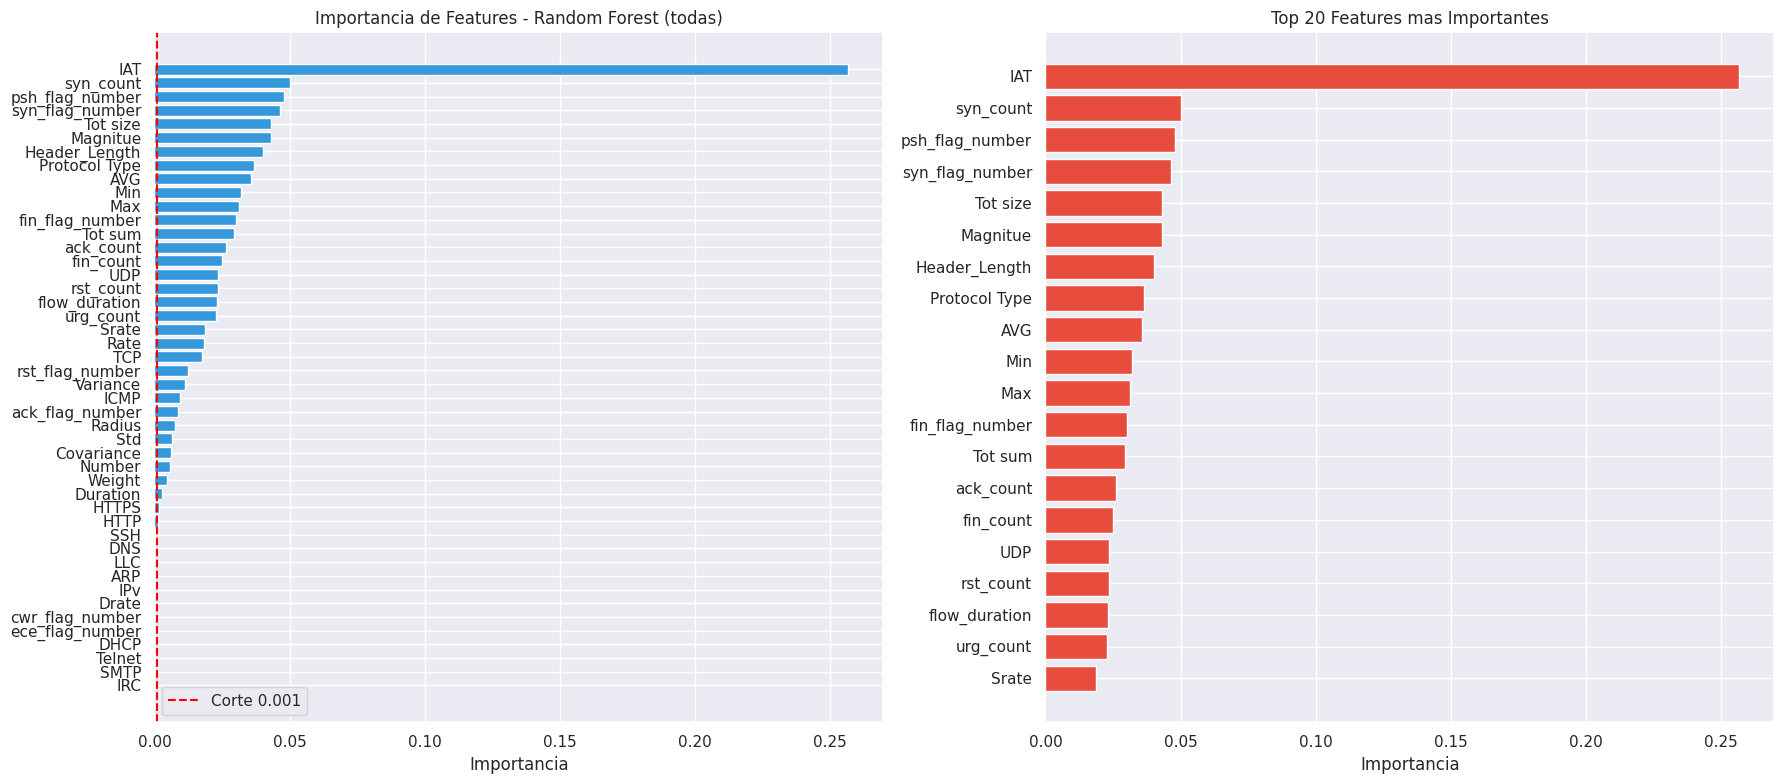

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# todas las features
axes[0].barh(importancias['feature'][::-1], importancias['importance'][::-1], color='#3498db')
axes[0].set_title("Importancia de Features - Random Forest (todas)")
axes[0].set_xlabel("Importancia")
axes[0].axvline(x=0.001, color='red', linestyle='--', label='Corte 0.001')
axes[0].legend()

# top 20
top20 = importancias.head(20)
axes[1].barh(top20['feature'][::-1], top20['importance'][::-1], color='#e74c3c')
axes[1].set_title("Top 20 Features mas Importantes")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/feature_importance.png", bbox_inches='tight')
plt.show()

## guardar subconjunto

In [6]:
CORTE = 0.001

features_seleccionadas = importancias[importancias['importance'] >= CORTE]['feature'].tolist()
features_eliminadas = importancias[importancias['importance'] < CORTE]['feature'].tolist()

print(f"Features seleccionadas ({len(features_seleccionadas)}): {features_seleccionadas}")
print(f"\nFeatures eliminadas ({len(features_eliminadas)}): {features_eliminadas}")

idx_seleccionadas = [list(feature_names).index(f) for f in features_seleccionadas]
X_train_sel = X_train[:, idx_seleccionadas]
X_test_sel  = X_test[:, idx_seleccionadas]

print(f"\nX_train_sel: {X_train_sel.shape}")
print(f"X_test_sel:  {X_test_sel.shape}")

np.save("/content/drive/MyDrive/X_train_sel.npy", X_train_sel)
np.save("/content/drive/MyDrive/X_test_sel.npy", X_test_sel)
np.save("/content/drive/MyDrive/features_seleccionadas.npy", np.array(features_seleccionadas))

print("\nArchivos guardados en Drive")

Features seleccionadas (34): ['IAT', 'syn_count', 'psh_flag_number', 'syn_flag_number', 'Tot size', 'Magnitue', 'Header_Length', 'Protocol Type', 'AVG', 'Min', 'Max', 'fin_flag_number', 'Tot sum', 'ack_count', 'fin_count', 'UDP', 'rst_count', 'flow_duration', 'urg_count', 'Srate', 'Rate', 'TCP', 'rst_flag_number', 'Variance', 'ICMP', 'ack_flag_number', 'Radius', 'Std', 'Covariance', 'Number', 'Weight', 'Duration', 'HTTPS', 'HTTP']

Features eliminadas (12): ['SSH', 'DNS', 'LLC', 'ARP', 'IPv', 'Drate', 'cwr_flag_number', 'ece_flag_number', 'DHCP', 'Telnet', 'SMTP', 'IRC']

X_train_sel: (992336, 34)
X_test_sel:  (248084, 34)

Archivos guardados en Drive


## JUSTIFICACION DEL CORTE DE FEATURES

* Corte aplicado     : importance >= 0.001
* Features originales: 46
* Features retenidas : 34
* Features eliminadas: 12
* Reduccion          : 26.1%

Features eliminadas por importancia < 0.001:
  - SSH: 5.88e-05
  - DNS: 1.34e-05
  - LLC: 1.25e-05
  - ARP: 1.02e-05
  - IPv: 9.88e-06
  - Drate: 7.29e-13
  - cwr_flag_number: 0.00e+00
  - ece_flag_number: 0.00e+00
  - DHCP: 0.00e+00
  - Telnet: 0.00e+00
  - SMTP: 0.00e+00
  - IRC: 0.00e+00

La feature mas importante es IAT con 0.2567

Las primeras 10 features acumulan el 63.2% de la importancia total